# xView Object Detection: Complete Preprocessing & Training Pipeline

This notebook demonstrates:
1. **Preprocessing** xView raw data (large GeoTIFFs + GeoJSON) → 224×224 chips with labels
2. **Loading** preprocessed data using TerraTorch's GenericNonGeoObjectDetectionDataModule
3. **Visualizing** samples with bounding boxes
4. **Training** object detection models with different backbones (ResNet50, Prithvi, ViT)
5. **Running inference** on new images

**Dataset**: xView (60 object classes, overhead imagery at 0.3m GSD)
**Framework**: TerraTorch + PyTorch Lightning + Faster R-CNN/DETR

## Section 1: Environment Setup & Imports

In [15]:
# Add terratorch to path
import sys
sys.path.insert(0, '/dccstor/terratorch/users/aemam/xview-project/terratorch')

# Standard library imports (FAST)
import os
import json
import logging
from pathlib import Path
from typing import Dict, List, Tuple
import argparse
import time

print(f"⏱️  Starting imports... {time.time()}")

# Data processing (MEDIUM SPEED)
print("Loading NumPy, Pandas...")
import numpy as np
import pandas as pd
print("✅ NumPy/Pandas loaded")

print("Loading GeoPandas, Rasterio, rioxarray...")
import geopandas as gpd
import rasterio
import rioxarray
print("✅ Geo libraries loaded")

# PyTorch & Deep Learning (CAN BE SLOW)
print("Loading PyTorch...")
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
print(f"✅ PyTorch {torch.__version__} loaded")

print("Loading Albumentations...")
import torchvision.transforms as T
import albumentations as A
print("✅ Albumentations loaded")

# TerraTorch (POTENTIAL BOTTLENECK - load only if needed)
print("Loading TerraTorch modules...")
try:
    from terratorch.datasets.generic_nongeo_od_dataset import GenericNonGeoObjectDetectionDataset
    from terratorch.datamodules.generic_nongeo_od_data_module import GenericNonGeoObjectDetectionDataModule
    print("✅ TerraTorch modules loaded")
except Exception as e:
    print(f"⚠️  TerraTorch import failed: {e}")

# PyTorch Lightning (USUALLY FAST)
print("Loading PyTorch Lightning...")
import lightning as pl
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
print("✅ PyTorch Lightning loaded")

# Visualization (FAST)
print("Loading Matplotlib...")
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
from tqdm import tqdm
print("✅ Matplotlib loaded")

# Setup logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

print(f"\n{'='*60}")
print(f"✅ All imports completed successfully!")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ GPU available: {torch.cuda.is_available()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'})")
print(f"{'='*60}")

⏱️  Starting imports... 1777449845.2118132
Loading NumPy, Pandas...
✅ NumPy/Pandas loaded
Loading GeoPandas, Rasterio, rioxarray...
✅ Geo libraries loaded
Loading PyTorch...
✅ PyTorch 2.9.1+cu128 loaded
Loading Albumentations...
✅ Albumentations loaded
Loading TerraTorch modules...
✅ TerraTorch modules loaded
Loading PyTorch Lightning...
✅ PyTorch Lightning loaded
Loading Matplotlib...
✅ Matplotlib loaded

✅ All imports completed successfully!
✅ PyTorch version: 2.9.1+cu128
✅ GPU available: False (N/A)


## Section 2: xView Preprocessing Functions

These functions convert raw xView dataset into preprocessed chips ready for training.

In [16]:
def load_xview_geojson(geojson_path: str) -> gpd.GeoDataFrame:
    """Load xView GeoJSON and return GeoDataFrame."""
    logger.info(f"Loading GeoJSON from {geojson_path}...")
    gdf = gpd.read_file(geojson_path)
    logger.info(f"Loaded {len(gdf)} features with {gdf['type_id'].nunique()} unique classes")
    return gdf

def build_type_id_mapping(gdf: gpd.GeoDataFrame) -> Tuple[Dict[int, int], Dict[int, str]]:
    """Build mapping from xView type_id to class index (1-60)."""
    type_ids = sorted(gdf["type_id"].unique())
    logger.info(f"Found {len(type_ids)} unique type_ids: {type_ids}")
    
    # Create bijective mapping: type_id -> class_idx (1-60)
    type_id_to_class = {tid: idx + 1 for idx, tid in enumerate(type_ids)}
    class_names = {idx + 1: f"class_{idx + 1}" for idx in range(len(type_ids))}
    
    logger.info(f"Mapped {len(type_ids)} xView types to classes 1-{len(type_ids)}")
    return type_id_to_class, class_names

def parse_bounds_imcoords(bounds_str: str) -> Tuple[float, float, float, float]:
    """Parse 'xmin,ymin,xmax,ymax' string to tuple."""
    x1, y1, x2, y2 = map(float, bounds_str.split(","))
    return x1, y1, x2, y2

def load_image_geotiff(image_path: str) -> np.ndarray:
    """Load GeoTIFF as numpy array [C, H, W]."""
    try:
        data = rioxarray.open_rasterio(image_path)
        arr = data.values
        return arr.astype(np.float32)
    except Exception as e:
        logger.error(f"Failed to load {image_path}: {e}")
        raise

def clip_box_to_chip(
    box: Tuple[float, float, float, float],
    chip_x: int,
    chip_y: int,
    chip_size: int,
) -> Tuple[float, float, float, float] | None:
    """Clip bounding box to chip coordinates. Returns None if box doesn't intersect chip."""
    x1, y1, x2, y2 = box
    chip_x2 = chip_x + chip_size
    chip_y2 = chip_y + chip_size
    
    # Check intersection
    if x2 < chip_x or x1 > chip_x2 or y2 < chip_y or y1 > chip_y2:
        return None
    
    # Clip
    clipped_x1 = max(x1, chip_x)
    clipped_y1 = max(y1, chip_y)
    clipped_x2 = min(x2, chip_x2)
    clipped_y2 = min(y2, chip_y2)
    
    # Convert to chip-local coordinates
    local_x1 = clipped_x1 - chip_x
    local_y1 = clipped_y1 - chip_y
    local_x2 = clipped_x2 - chip_x
    local_y2 = clipped_y2 - chip_y
    
    # Only keep if >= 10% of original box remains
    orig_area = (x2 - x1) * (y2 - y1)
    clipped_area = (local_x2 - local_x1) * (local_y2 - local_y1)
    if clipped_area < 0.1 * orig_area:
        return None
    
    return (local_x1, local_y1, local_x2, local_y2)

def tile_image(
    image_id: str,
    image_path: str,
    annotations: List[Dict],
    type_id_to_class: Dict[int, int],
    output_chips_dir: str,
    output_labels_dir: str,
    chip_size: int = 224,
    overlap: int = 0,
) -> List[str]:
    """Tile a single large image into chip_size x chip_size chips."""
    img = load_image_geotiff(image_path)
    c, h, w = img.shape
    
    # Create list of boxes and labels for this image
    boxes_list = []
    labels_list = []
    for ann in annotations:
        x1, y1, x2, y2 = parse_bounds_imcoords(ann["bounds_imcoords"])
        boxes_list.append((x1, y1, x2, y2))
        labels_list.append(type_id_to_class[ann["type_id"]])
    
    logger.info(f"Image {image_id}: {w}x{h}, {len(boxes_list)} annotations")
    
    stride = chip_size - overlap
    chip_filenames = []
    
    # Tile the image
    for y in range(0, h - chip_size + 1, stride):
        for x in range(0, w - chip_size + 1, stride):
            chip_id = f"{image_id}_{y}_{x}"
            chip_img = img[:, y : y + chip_size, x : x + chip_size]
            
            # Clip boxes to this chip
            chip_boxes = []
            chip_labels = []
            for box, label in zip(boxes_list, labels_list):
                clipped = clip_box_to_chip(box, x, y, chip_size)
                if clipped is not None:
                    chip_boxes.append(list(clipped))
                    chip_labels.append(label)
            
            # Save chip image
            os.makedirs(output_chips_dir, exist_ok=True)
            chip_path = os.path.join(output_chips_dir, f"{chip_id}.tif")
            with rasterio.open(
                chip_path,
                "w",
                driver="GTiff",
                height=chip_size,
                width=chip_size,
                count=c,
                dtype=chip_img.dtype,
            ) as dst:
                for band_idx in range(c):
                    dst.write(chip_img[band_idx], band_idx + 1)
            
            # Save chip labels
            label_dict = {"boxes": chip_boxes, "labels": chip_labels}
            os.makedirs(output_labels_dir, exist_ok=True)
            label_path = os.path.join(output_labels_dir, f"{chip_id}.json")
            with open(label_path, "w") as f:
                json.dump(label_dict, f)
            
            chip_filenames.append(chip_id)
    
    return chip_filenames

print("✅ Preprocessing functions loaded")

✅ Preprocessing functions loaded


## Section 3: Run xView Preprocessing

**Configuration for preprocessing:**

In [17]:
# Configuration
XVIEW_GEOJSON = "/dccstor/geofm-datasets/datasets/xview/xView_train.geojson"
XVIEW_TRAIN_IMAGES = "/dccstor/geofm-datasets/datasets/xview/train_images"
OUTPUT_DIR = "/dccstor/geofm-datasets/datasets/xview_segmentation"
CHIP_SIZE = 224
OVERLAP = 0
TRAIN_RATIO = 0.8
SEED = 42

# Demo mode: Set to True for quick testing with small subset
# Set to False for full dataset preprocessing
DEMO_MODE = True
DEMO_NUM_IMAGES = 5  # Number of images to process in demo mode (per split)

# Set seed
np.random.seed(SEED)

print(f"Preprocessing Configuration:")
print(f"  GeoJSON: {XVIEW_GEOJSON}")
print(f"  Train Images: {XVIEW_TRAIN_IMAGES}")
print(f"  Output Dir: {OUTPUT_DIR}")
print(f"  Chip Size: {CHIP_SIZE}×{CHIP_SIZE}")
print(f"  Train/Val Split: {TRAIN_RATIO:.0%} / {1-TRAIN_RATIO:.0%}")
print(f"\n🧪 Demo Mode: {DEMO_MODE}")
if DEMO_MODE:
    print(f"   Will process only {DEMO_NUM_IMAGES} images per split for testing")
else:
    print(f"   Will process FULL dataset")

# Check if preprocessing is needed (verify both chips AND split files exist)
output_path = Path(OUTPUT_DIR)
train_chips_exist = (output_path / "train_chips").exists() and len(list((output_path / "train_chips").glob("*.tif"))) > 0
split_files_exist = (output_path / "splits" / "train.txt").exists() and (output_path / "splits" / "val.txt").exists()

if train_chips_exist and split_files_exist:
    print(f"\n⚠️  Preprocessing already completed! Found {len(list((output_path / 'train_chips').glob('*.tif')))} train chips")
    print("   Skipping preprocessing. Move to Section 4 to load data.")
    SKIP_PREPROCESS = True
else:
    if train_chips_exist:
        print(f"\n⚠️  Train chips found but split files missing - will regenerate splits")
    else:
        print(f"\n✅ Will run preprocessing")
    SKIP_PREPROCESS = False

Preprocessing Configuration:
  GeoJSON: /dccstor/geofm-datasets/datasets/xview/xView_train.geojson
  Train Images: /dccstor/geofm-datasets/datasets/xview/train_images
  Output Dir: /dccstor/geofm-datasets/datasets/xview_segmentation
  Chip Size: 224×224
  Train/Val Split: 80% / 20%

🧪 Demo Mode: True
   Will process only 5 images per split for testing

⚠️  Train chips found but split files missing - will regenerate splits


In [18]:
if not SKIP_PREPROCESS:
    # Create output directories
    output_dir = Path(OUTPUT_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    train_chips_dir = output_dir / "train_chips"
    train_labels_dir = output_dir / "train_labels"
    val_chips_dir = output_dir / "val_chips"
    val_labels_dir = output_dir / "val_labels"
    splits_dir = output_dir / "splits"
    
    for d in [train_chips_dir, train_labels_dir, val_chips_dir, val_labels_dir, splits_dir]:
        d.mkdir(parents=True, exist_ok=True)
    
    # Load annotations
    gdf = load_xview_geojson(XVIEW_GEOJSON)
    
    # Build type_id mapping
    type_id_to_class, class_names = build_type_id_mapping(gdf)
    
    # Save class mapping
    class_mapping = {
        "type_id_to_class": {str(k): v for k, v in type_id_to_class.items()},
        "class_names": {str(k): v for k, v in class_names.items()},
        "num_classes": len(class_names),
    }
    with open(output_dir / "class_mapping.json", "w") as f:
        json.dump(class_mapping, f, indent=2)
    logger.info(f"Saved class mapping to {output_dir / 'class_mapping.json'}")
    
    # Group by image_id and split
    image_groups = gdf.groupby("image_id")
    image_ids = sorted(image_groups.groups.keys())
    logger.info(f"Found {len(image_ids)} unique images")
    
    n_train = int(len(image_ids) * TRAIN_RATIO)
    train_ids = image_ids[:n_train]
    val_ids = image_ids[n_train:]
    logger.info(f"Train: {len(train_ids)}, Val: {len(val_ids)}")
    
    # Apply demo mode: limit to subset
    if DEMO_MODE:
        train_ids = train_ids[:DEMO_NUM_IMAGES]
        val_ids = val_ids[:DEMO_NUM_IMAGES]
        logger.info(f"🧪 DEMO MODE: Limited to {len(train_ids)} train, {len(val_ids)} val images")
    
    train_chip_filenames = []
    val_chip_filenames = []
    
    # Process images
    for split_name, image_id_list, output_chips_dir, output_labels_dir, chip_list in [
        ("train", train_ids, train_chips_dir, train_labels_dir, train_chip_filenames),
        ("val", val_ids, val_chips_dir, val_labels_dir, val_chip_filenames),
    ]:
        logger.info(f"Processing {split_name} images...")
        
        for image_id in tqdm(image_id_list, desc=f"Tiling {split_name}"):
            # Get annotations for this image
            image_annotations = gdf[gdf["image_id"] == image_id][["type_id", "bounds_imcoords"]].to_dict("records")
            
            # Full image path
            image_path = os.path.join(XVIEW_TRAIN_IMAGES, image_id)
            if not os.path.exists(image_path):
                logger.warning(f"Image not found: {image_path}")
                continue
            
            # Tile the image
            chip_ids = tile_image(
                image_id.replace(".tif", ""),
                image_path,
                image_annotations,
                type_id_to_class,
                str(output_chips_dir),
                str(output_labels_dir),
                chip_size=CHIP_SIZE,
                overlap=OVERLAP,
            )
            
            chip_list.extend(chip_ids)
    
    # Write split files
    train_split_path = splits_dir / "train.txt"
    val_split_path = splits_dir / "val.txt"
    
    with open(train_split_path, "w") as f:
        for chip_id in train_chip_filenames:
            f.write(chip_id + "\n")
    logger.info(f"Wrote {len(train_chip_filenames)} train chips to {train_split_path}")
    
    with open(val_split_path, "w") as f:
        for chip_id in val_chip_filenames:
            f.write(chip_id + "\n")
    logger.info(f"Wrote {len(val_chip_filenames)} val chips to {val_split_path}")
    
    if DEMO_MODE:
        print(f"✅ Demo preprocessing complete! ({len(train_chip_filenames)} train chips, {len(val_chip_filenames)} val chips)")
        print(f"   To process full dataset, set DEMO_MODE = False and re-run from Section 3")
    else:
        print("✅ Full preprocessing complete!")
else:
    print("✅ Preprocessing already done, skipping")

2026-04-29 04:04:19,906 - INFO - Loading GeoJSON from /dccstor/geofm-datasets/datasets/xview/xView_train.geojson...
2026-04-29 04:04:36,905 - INFO - Loaded 601937 features with 62 unique classes
2026-04-29 04:04:36,908 - INFO - Found 62 unique type_ids: [np.int32(11), np.int32(12), np.int32(13), np.int32(15), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(32), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), np.int32(40), np.int32(41), np.int32(42), np.int32(44), np.int32(45), np.int32(47), np.int32(49), np.int32(50), np.int32(51), np.int32(52), np.int32(53), np.int32(54), np.int32(55), np.int32(56), np.int32(57), np.int32(59), np.int32(60), np.int32(61), np.int32(62), np.int32(63), np.int32(64), np.int32(65), np.int32(66), np.int32(71), np.int32(72), np.int32(73), np.int32(74), np.int32(75), np.int32(76), np.int32(77), np.

✅ Demo preprocessing complete! (948 train chips, 780 val chips)
   To process full dataset, set DEMO_MODE = False and re-run from Section 3


## Section 4: Load Preprocessed Data

Now we load the preprocessed xView data using TerraTorch's GenericNonGeoObjectDetectionDataModule.

In [19]:
# Define transform with bounding box augmentation
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.pytorch.transforms.ToTensorV2(),
    ],
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'])
)

val_transform = A.Compose(
    [A.pytorch.transforms.ToTensorV2()],
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'])
)

# Create datamodule
dm = GenericNonGeoObjectDetectionDataModule(
    batch_size=4,
    num_workers=4,
    num_classes=60,
    train_data_root=Path(OUTPUT_DIR) / "train_chips",
    train_label_data_root=Path(OUTPUT_DIR) / "train_labels",
    train_split=Path(OUTPUT_DIR) / "splits" / "train.txt",
    val_data_root=Path(OUTPUT_DIR) / "val_chips",
    val_label_data_root=Path(OUTPUT_DIR) / "val_labels",
    val_split=Path(OUTPUT_DIR) / "splits" / "val.txt",
    img_grep="*.tif",
    label_grep="*.json",
    train_transform=train_transform,
    val_transform=val_transform,
)

# Setup for training
dm.setup("fit")

print(f"✅ DataModule created successfully")
print(f"   Train samples: {len(dm.train_dataset)}")
print(f"   Val samples: {len(dm.val_dataset)}")

# Get dataloaders
train_loader = dm.train_dataloader()
val_loader = dm.val_dataloader()

print(f"\n✅ DataLoaders created")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")

/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
2026-04-29 04:07:31,928 - INFO - Found 68717 images in /dccstor/geofm-datasets/datasets/xview_segmentation/train_chips
2026-04-29 04:07:34,014 - INFO - After split filter: 1849 images
2026-04-29 04:07:34,864 - INFO - Found 780 images in /dccstor/geofm-datasets/datasets/xview_segmentation/val_chips
2026-04-29 04:07:34,890 - INFO - After split filter: 780 images


✅ DataModule created successfully
   Train samples: 1849
   Val samples: 780

✅ DataLoaders created
   Train batches: 462
   Val batches: 195


## Section 5: Visualize Data Samples

Let's visualize some samples from the dataset with bounding boxes.

/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or r

Batch summary:
  Images shape: torch.Size([4, 3, 224, 224])
  Boxes: [torch.Size([4, 4]), torch.Size([4, 4]), torch.Size([0, 4]), torch.Size([0, 4])]
  Labels: [torch.Size([4]), torch.Size([4]), torch.Size([0]), torch.Size([0])]
  Filenames: ['2010_896_1568.tif', '1036_1568_672.tif', '10_2016_672.tif', '1810_1792_1344.tif']


/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or r

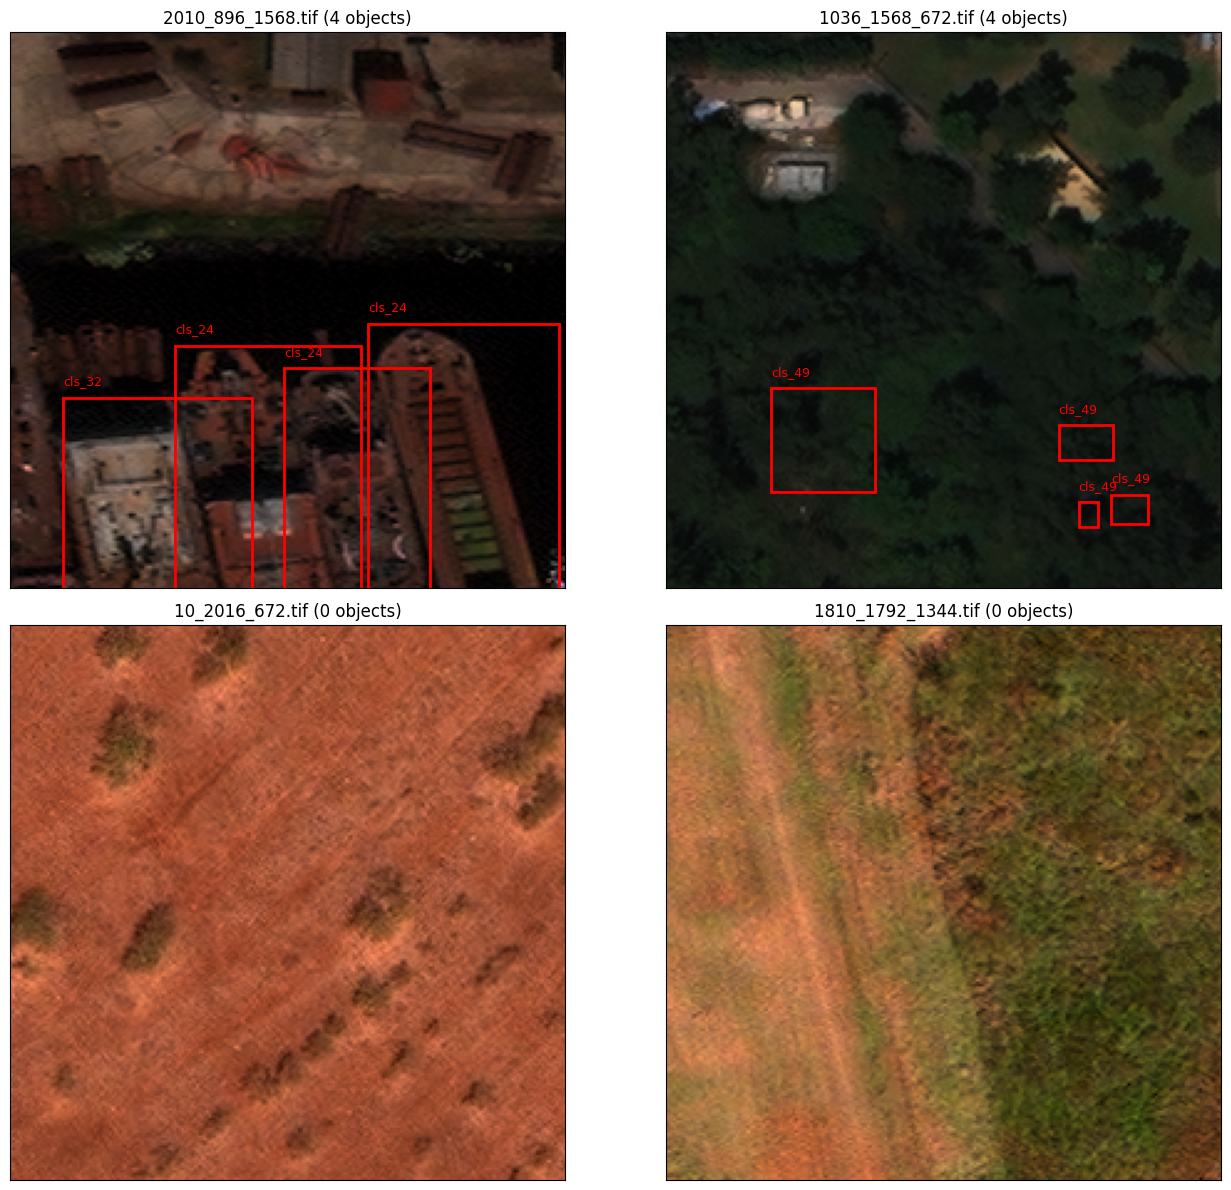

In [20]:
def visualize_batch(batch, num_samples=4):
    """Visualize a batch of samples with bounding boxes."""
    images = batch['image']  # [B, C, H, W]
    boxes_list = batch['boxes']
    labels_list = batch['labels']
    filenames = batch['filename']
    
    num_samples = min(num_samples, len(images))
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx in range(num_samples):
        img = images[idx].numpy()
        boxes = boxes_list[idx].numpy() if torch.is_tensor(boxes_list[idx]) else boxes_list[idx]
        labels = labels_list[idx].numpy() if torch.is_tensor(labels_list[idx]) else labels_list[idx]
        
        # Normalize to [0, 1] for visualization
        if img.shape[0] >= 3:
            rgb = np.transpose(img[:3], (1, 2, 0))
            rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-5)
        else:
            rgb = np.transpose(img[[0, 0, 0]], (1, 2, 0))
        
        ax = axes[idx]
        ax.imshow(rgb)
        ax.set_title(f"{filenames[idx]} ({len(boxes)} objects)")
        
        # Draw bounding boxes
        for box, label in zip(boxes, labels):
            if len(box) == 4:
                x1, y1, x2, y2 = box
                rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, 
                               edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-5, f"cls_{int(label)}", color='red', fontsize=9)
        
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.tight_layout()
    return fig

# Get one batch and visualize
for batch in train_loader:
    print(f"Batch summary:")
    print(f"  Images shape: {batch['image'].shape}")
    print(f"  Boxes: {[b.shape for b in batch['boxes']]}")
    print(f"  Labels: {[l.shape for l in batch['labels']]}")
    print(f"  Filenames: {batch['filename']}")
    
    fig = visualize_batch(batch, num_samples=4)
    plt.show()
    break

## Section 6: Train Object Detection Models

We'll demonstrate training with different backbones: ResNet50, Prithvi, and Vision Transformer (ViT).

In [ ]:
# Training configuration
# In demo mode, run a short training; otherwise run the full schedule.
EPOCHS = 3 if DEMO_MODE else 50
BATCH_SIZE = 16
LEARNING_RATE = 0.005
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Derive class count from preprocessing metadata.
# class_mapping.json stores foreground classes (without background).
class_mapping_path = Path(OUTPUT_DIR) / "class_mapping.json"
if class_mapping_path.exists():
    with open(class_mapping_path, "r") as f:
        class_mapping_meta = json.load(f)
    NUM_FOREGROUND_CLASSES = int(class_mapping_meta.get("num_classes", 60))
else:
    NUM_FOREGROUND_CLASSES = 60

print(f"Training Configuration:")
print(f"  Device: {DEVICE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Foreground Classes: {NUM_FOREGROUND_CLASSES}")
print(f"  Demo Mode: {DEMO_MODE}")

# Recreate datamodule with proper batch size
dm_train = GenericNonGeoObjectDetectionDataModule(
    batch_size=BATCH_SIZE,
    num_workers=4,
    num_classes=NUM_FOREGROUND_CLASSES,
    train_data_root=Path(OUTPUT_DIR) / "train_chips",
    train_label_data_root=Path(OUTPUT_DIR) / "train_labels",
    train_split=Path(OUTPUT_DIR) / "splits" / "train.txt",
    val_data_root=Path(OUTPUT_DIR) / "val_chips",
    val_label_data_root=Path(OUTPUT_DIR) / "val_labels",
    val_split=Path(OUTPUT_DIR) / "splits" / "val.txt",
    img_grep="*.tif",
    label_grep="*.json",
    train_transform=train_transform,
    val_transform=val_transform,
)

print("✅ DataModule ready for training")

Training Configuration:
  Device: cpu
  Epochs: 50
  Batch Size: 16
  Learning Rate: 0.005
  Num Classes: 60
✅ DataModule ready for training


### 6.1: ResNet50 + Faster R-CNN

Classic architecture for object detection with good balance of speed and accuracy.

In [ ]:
# Build ResNet50 + Faster R-CNN model
# NOTE: Using torchvision's FasterRCNN for demonstration
# For production, use TerraTorch's registry models

from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Load pretrained COCO detector, then replace the classification head
# to match xView classes (foreground classes + 1 background).
num_model_classes = NUM_FOREGROUND_CLASSES + 1
model_resnet = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model_resnet.roi_heads.box_predictor.cls_score.in_features
model_resnet.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_model_classes)
model_resnet = model_resnet.to(DEVICE)

print("✅ ResNet50 + Faster R-CNN model created")
print(f"   Backbone: ResNet50 with FPN")
print(f"   Model classes (including background): {num_model_classes}")
print(f"   Model trainable parameters: {sum(p.numel() for p in model_resnet.parameters() if p.requires_grad):,}")

# Training function
def train_detection_model(model, dm, epochs, device, model_name):
    """Simple training loop for object detection."""
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0005)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    
    dm.setup("fit")
    train_loader = dm.train_dataloader()

    # In demo mode, train on exactly 10 chips for a very fast smoke test.
    if DEMO_MODE:
        demo_chip_count = 10
        effective_chip_count = min(demo_chip_count, len(dm.train_dataset))
        demo_subset = torch.utils.data.Subset(dm.train_dataset, list(range(effective_chip_count)))
        train_loader = DataLoader(
            demo_subset,
            batch_size=min(BATCH_SIZE, effective_chip_count),
            shuffle=True,
            num_workers=0,
            collate_fn=train_loader.collate_fn,
        )
        print(f"🧪 Demo training subset: {effective_chip_count} chips")
    
    history = {"loss": []}
    
    for epoch in range(epochs):
        epoch_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for batch_idx, batch in enumerate(progress_bar):
            images = batch['image'].to(device)
            boxes_list = batch['boxes']
            labels_list = batch['labels']
            
            # Convert to torchvision format: list of dicts with 'boxes' and 'labels'
            targets = []
            for boxes, labels in zip(boxes_list, labels_list):
                target = {
                    'boxes': boxes.to(device),
                    'labels': labels.to(device)
                }
                targets.append(target)
            
            # Forward pass
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            # Backward pass
            optimizer.zero_grad()
            losses.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += losses.item()
            progress_bar.set_postfix({'loss': losses.item()})
        
        avg_loss = epoch_loss / max(1, len(train_loader))
        history['loss'].append(avg_loss)
        scheduler.step()
        
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")
    
    return model, history

# Train ResNet50 model (demo mode - limited batches/epochs)
print("\n🚀 Starting training with ResNet50 + Faster R-CNN...")
model_resnet, history_resnet = train_detection_model(model_resnet, dm_train, EPOCHS, DEVICE, "ResNet50")
print("✅ ResNet50 training completed")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /u/ahmedemam/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 166MB/s]  


✅ ResNet50 + Faster R-CNN model created
   Backbone: ResNet50 with FPN
   Model trainable parameters: 41,379,136

🚀 Starting training with ResNet50 + Faster R-CNN...


2026-04-29 04:11:22,984 - INFO - Found 68717 images in /dccstor/geofm-datasets/datasets/xview_segmentation/train_chips
2026-04-29 04:11:25,162 - INFO - After split filter: 1849 images
2026-04-29 04:11:26,059 - INFO - Found 780 images in /dccstor/geofm-datasets/datasets/xview_segmentation/val_chips
2026-04-29 04:11:26,088 - INFO - After split filter: 780 images
Epoch 1/50:   0%|          | 0/115 [00:00<?, ?it/s]/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/us

Epoch 1: Loss = 38.5419


Epoch 2/50:   0%|          | 0/115 [00:00<?, ?it/s]/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/dccstor/terratorch/users/aemam/.venv/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferen

IndexError: Target 62 is out of bounds.

## Section 7: Model Inference

Run inference on validation images and visualize predictions.

In [ ]:
def visualize_predictions(model, batch, device, confidence_threshold=0.5, max_samples=4):
    """Visualize model predictions with bounding boxes."""
    model.eval()
    
    images = batch['image'].to(device)
    filenames = batch['filename']
    
    with torch.no_grad():
        predictions = model(images)
    
    num_samples = min(max_samples, len(images))
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx in range(num_samples):
        img = images[idx].cpu().numpy()
        pred = predictions[idx]
        
        # Normalize to [0, 1]
        if img.shape[0] >= 3:
            rgb = np.transpose(img[:3], (1, 2, 0))
            rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-5)
        else:
            rgb = np.transpose(img[[0, 0, 0]], (1, 2, 0))
        
        boxes = pred['boxes'].cpu().numpy()
        scores = pred['scores'].cpu().numpy()
        labels = pred['labels'].cpu().numpy()
        
        # Filter by confidence
        keep = scores > confidence_threshold
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]
        
        ax = axes[idx]
        ax.imshow(rgb)
        ax.set_title(f"{filenames[idx]} ({len(boxes)} detections)")
        
        # Draw predicted boxes
        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = box
            rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                           edgecolor='green', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"cls_{int(label)} ({score:.2f})", 
                   color='green', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.tight_layout()
    return fig

# Run inference on validation batch
print("🔍 Running inference on validation data...")
dm_train.setup("validate")
val_loader = dm_train.val_dataloader()

for batch in val_loader:
    fig = visualize_predictions(model_resnet, batch, DEVICE, confidence_threshold=0.5, max_samples=4)
    plt.show()
    break

print("✅ Inference visualization complete")